# `orbital-game` — 2D RT workflow walkthrough

In-plane relative motion only: `RTState` per vehicle (radial + along-track) under HCW-RT dynamics. Cross-track is dropped — the state is 4-dim `[r, t, ṙ, ṫ]` and the action is 2-dim `[Δv_r, Δv_t]`.

Use this when:
- The scenario lives near the orbital plane and cross-track motion is uninteresting
- You want a smaller state space for faster POMDP planning
- You're prototyping a new policy and don't need 3D fidelity yet

Steps covered:

1. Build a `ScenarioConfig` for HCW-RT dynamics
2. Construct an `OrbitalGameEnv` from the config
3. Define a simple defender policy + null policy-state initializer
4. Run two `rollout`s with different seeds
5. Visualize R-T trajectories
6. Plot reward curves and propellant-mass curves
7. Save and reload one rollout via HDF5

**Setup.** Run with `uv` (Jupyter is not in the project deps; the easiest way is):

```bash
uv run --with jupyter --with ipykernel jupyter notebook examples/workflow_2d_rt.ipynb
```

For the full 3D variant, see `workflow_3d_rtn.ipynb`.

In [1]:
# Auto-reload edited library code without a kernel restart. Run this cell
# again after editing any orbital_game module to pick up the changes.
%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from orbital_game import OrbitalGameEnv, ScenarioConfig, VehicleParamsSpec, rollout, save_run, load_run
from orbital_game.hva import HVAState
from orbital_game.registry import DynamicsKey, StateComponentKey
from orbital_game.sampling.reference import GaussianAroundNominal
from orbital_game.viz.trajectories import plot_rt
from orbital_game.viz.summaries import plot_reward_curve

## 1. Build a 2D RT scenario

Three things change relative to the 3D variant:

- `defender_components`/`intruder_components` use `StateComponentKey.RT` (4-dim) instead of `RTN` (6-dim)
- `truth_dynamics` and `planning_dynamics` are set to `DynamicsKey.HCW_RT`
- The IC sampler's nominal vectors are 4-dim `[r, t, ṙ, ṫ]` instead of 6-dim

Everything else (HVA, vehicle params, dt/horizon) is identical.

In [2]:
cfg = ScenarioConfig(
    n_defenders=1,
    n_intruders=1,
    epoch_mjd_utc=60067.0,
    hva=HVAState(
        position_eci=jnp.array([7000e3, 0.0, 0.0]),
        velocity_eci=jnp.array([0.0, 7.5e3, 0.0]),
    ),
    defender_components=(StateComponentKey.RT, StateComponentKey.MASS),
    intruder_components=(StateComponentKey.RT,),
    defender_params=VehicleParamsSpec(
        dry_mass_kg=100.0, propellant_mass_kg=10.0, isp_s=220.0, max_thrust_n=5.0,
    ),
    intruder_params=VehicleParamsSpec(
        dry_mass_kg=50.0, propellant_mass_kg=5.0, isp_s=200.0, max_thrust_n=2.0,
    ),
    ic_sampler=GaussianAroundNominal(
        # 4-dim nominal: [r, t, ṙ, ṫ]
        nominal_defender_state=jnp.array([[1000.0, 0.0, 0.0, 0.0]]),
        nominal_intruder_state=jnp.array([[-1000.0, 0.0, 0.0, 0.0]]),
        sigma_pos=10.0,
        sigma_vel=0.1,
    ),
    truth_dynamics=DynamicsKey.HCW_RT,
    planning_dynamics=DynamicsKey.HCW_RT,
    dt=10.0,
    max_horizon_s=2.0*60.0*96.0,
    seed=0,
)

print(f"max_steps (derived): {cfg.max_steps}")
print(f"truth dynamics:     {cfg.truth_dynamics}")
print(f"defender components: {cfg.defender_components}")

max_steps (derived): 1152
truth dynamics:     hcw_rt
defender components: (<StateComponentKey.RT: 'rt'>, <StateComponentKey.MASS: 'mass'>)


## 2. Construct the environment

`OrbitalGameEnv` resolves the dynamics, actuator, and pluggables based on the config. Because we picked `HCW_RT`, the intruder policy's action dim is 2 (not 3) and the dynamics step takes a 4-dim state.

In [3]:
env = OrbitalGameEnv(cfg)
print(f"mean motion (rad/s): {env.mean_motion:.3e}")
print(f"layout flat dim:     {env.layout.flat_dim}")  # 4 RT + 1 mass + 4 intruder RT = 9

mean motion (rad/s): 1.098e-03
layout flat dim:     9


## 3. Define a policy and run two rollouts

The default policy commands zero Δv each step — the defender takes no maneuvers, so the rollout shows **pure HCW-RT dynamics** evolving from the sampled IC. With an initial radial offset of ~1 km and zero relative velocity, you should see the classic in-plane leader-follower drift: the defender curves away in the negative along-track (T) direction with a slow radial oscillation about the initial offset.

A commented-out alternative gives the defender small random Gaussian impulses each step — switch to it if you want to see propellant depletion in section 6.

`init_ps` returns `None` — we don't track belief in this demo. Action shape is `(N_defenders, 2)` for HCW-RT.

In [4]:
# Default policy: zero-control — no maneuvers, pure HCW-RT dynamics.
def policy(policy_state, obs, key, t):
    del obs, key, t
    return jnp.zeros((cfg.n_defenders, 2)), policy_state

# Alternative: small random Gaussian impulses each step (m/s). Uncomment to
# enable; the defender will perturb its trajectory and visibly deplete
# propellant. Action shape is (N_defenders, 2) for HCW-RT.
# def policy(policy_state, obs, key, t):
#     del obs, t
#     return jax.random.normal(key, (cfg.n_defenders, 2)) * 0.5, policy_state

def init_ps(config, env_state, key):
    del config, env_state, key
    return None

key1, key2 = jax.random.split(jax.random.PRNGKey(42), 2)
traj1 = rollout(env, policy, init_ps, key1, n_steps=cfg.max_steps)
traj2 = rollout(env, policy, init_ps, key2, n_steps=cfg.max_steps)

print(f"rollout 1 episode return:  {float(traj1.reward.sum()):.2f}")
print(f"rollout 2 episode return:  {float(traj2.reward.sum()):.2f}")
print(f"rollout 1 first defender RT pos: {traj1.env_state.defenders.rt[0, 0, :2]}")
print(f"rollout 2 first defender RT pos: {traj2.env_state.defenders.rt[0, 0, :2]}")

rollout 1 episode return:  -43168736.00
rollout 2 episode return:  -44015208.00
rollout 1 first defender RT pos: [1003.2114      2.168314]
rollout 2 first defender RT pos: [979.6423     3.865673]


## 4. Visualize the in-plane trajectories

Only `plot_rt` makes sense in 2D — there is no cross-track (N) component, so R-N / T-N / 3D RTN plots don't apply. The trace is the defender's `(r, t)` position over time, with both rollouts overlaid for comparison.

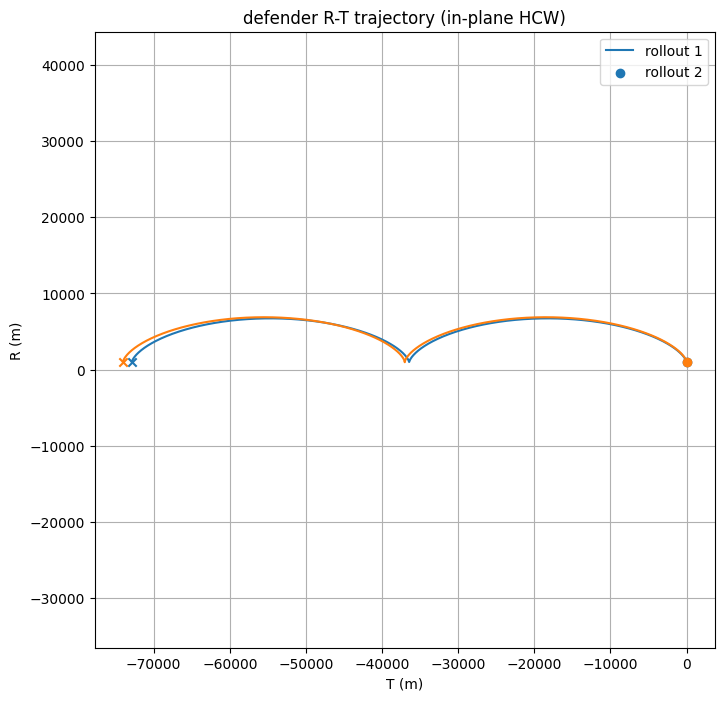

In [5]:
rt1 = traj1.env_state.defenders.rt  # (T, N=1, 4)
rt2 = traj2.env_state.defenders.rt

fig, ax = plt.subplots(figsize=(8, 8))
plot_rt(rt1, ax=ax, label="rollout 1")
plot_rt(rt2, ax=ax, label="rollout 2")
ax.legend()
ax.set_title("defender R-T trajectory (in-plane HCW)")
plt.show()

## 5. Reward curves

`DistanceToHVA` automatically uses 2D distance for RT scenarios — it reads `defenders.rt[:, :2]` for position and norms over those two components.

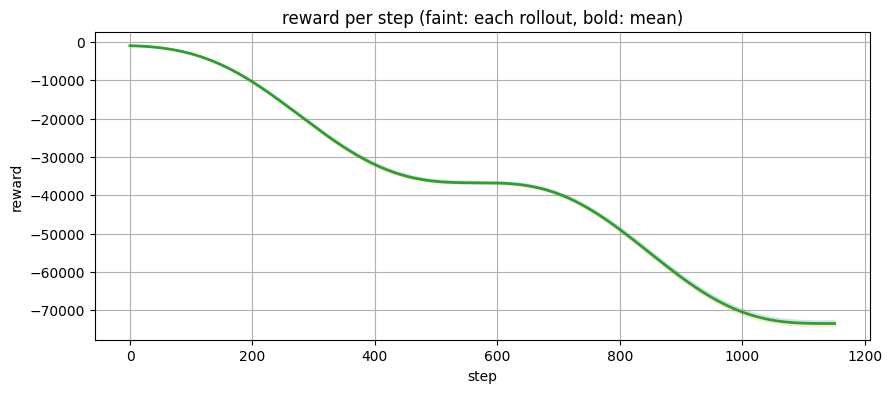

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
rewards = jnp.stack([traj1.reward, traj2.reward], axis=0)  # (B=2, T)
plot_reward_curve(rewards, ax=ax)
ax.set_title("reward per step (faint: each rollout, bold: mean)")
plt.show()

## 6. Propellant mass over time

Because the defender's `Mass` component is in `defender_components`, the impulsive actuator deposits a rocket-equation Δm into `propellant_mass` each step — but only when the actuator command is non-zero. With the default zero-control policy, propellant stays at its initial 10 kg (flat line). Uncomment the random-impulse policy in section 3 to see propellant deplete.

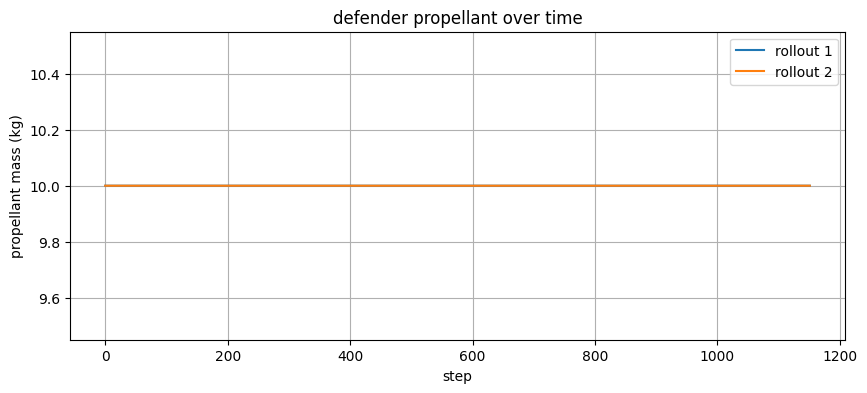

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(traj1.env_state.defenders.propellant_mass[:, 0], label="rollout 1")
ax.plot(traj2.env_state.defenders.propellant_mass[:, 0], label="rollout 2")
ax.set_xlabel("step"); ax.set_ylabel("propellant mass (kg)")
ax.set_title("defender propellant over time"); ax.grid(True); ax.legend()
plt.show()

## 7. Persistence — save and reload via HDF5

Save/load works the same regardless of dynamics choice. The flat trajectory dict from `load_run` will have keys like `"env_state.defenders.rt"` (instead of `.rtn`) for a 2D scenario.

In [8]:
import tempfile, pathlib

tmp = pathlib.Path(tempfile.mkdtemp())
out = tmp / "rollout_1.h5"
save_run(out, cfg, traj1)

loaded_cfg, loaded_traj = load_run(out)

print(f"file written:           {out}  ({out.stat().st_size:,} bytes)")
print(f"loaded config matches:  {loaded_cfg.n_defenders == cfg.n_defenders and loaded_cfg.dt == cfg.dt}")
print(f"trajectory keys:        {sorted(loaded_traj.keys())[:6]} ...")
print(f"reward round-trips:     {bool(jnp.allclose(loaded_traj['reward'], traj1.reward))}")

file written:           /var/folders/66/25bqc2bn19bb84ddx70zwv9m0000gn/T/tmpak0jxpb7/rollout_1.h5  (117,438 bytes)
loaded config matches:  True
trajectory keys:        ['action', 'done', 'env_state.defenders.propellant_mass', 'env_state.defenders.rt', 'env_state.hva.position_eci', 'env_state.hva.velocity_eci'] ...
reward round-trips:     True


## Next steps

Same pluggable points as the 3D notebook, plus the option to upgrade dimensionality once your 2D prototype is working. The mapping to swap a scenario from 2D → 3D is mechanical:

- `StateComponentKey.RT` → `StateComponentKey.RTN`
- `DynamicsKey.HCW_RT` → `DynamicsKey.HCW_RTN`
- IC nominal vectors gain two columns (cross-track + cross-track-velocity)
- Policy action shape goes from `(N, 2)` → `(N, 3)`

All the framework pieces (rollout, save/load, reward, termination, plots) work in both regimes.